### Imports

In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d

In [2]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
import constants
from plot import Plot
from fitting import IterativeSolverMethod
from preprocess_vis import Gridding
from geometry import Geometry

# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

### Functions

In [3]:
def _get_atol_rtol(name, b_norm, atol=0., rtol=1e-5):
    """
    A helper function to handle tolerance normalization
    """
    if atol == 'legacy' or atol is None or atol < 0:
        msg = (f"'scipy.sparse.linalg.{name}' called with invalid `atol`={atol}; "
            "if set, `atol` must be a real, non-negative number.")
        raise ValueError(msg)
    
    print(f'         * rtol: {float(rtol)}')
    
    atol = max(float(atol), float(rtol) * float(b_norm))
    print(f'         * final tolerance: {atol}')
    
    return atol, rtol
    
def cg_(A, b, x0=None, *, rtol=1e-7, atol=0., maxiter=None, M=None, callback=None):
    A, M, x, b, postprocess = make_system(A, M, x0, b)
    bnrm2 = np.linalg.norm(b)
    
    atol, _ = _get_atol_rtol('cg', bnrm2, atol, rtol)
    
    if bnrm2 == 0:
        return postprocess(b), 0
    
    n = len(b)
    
    if maxiter is None:
        maxiter = int(n*1e4)
    print("maxiter: ", maxiter)
    
    dotprod = np.vdot if np.iscomplexobj(x) else np.dot
    
    matvec = A.matvec
    psolve = M.matvec
    r = b - matvec(x) if x.any() else b.copy()
    
    # Dummy value to initialize var, silences warnings
    rho_prev, p = None, None
    
    p_prev = None
    r_prev = None
    
    for iteration in range(maxiter):
        print("iteration: ", iteration)
        print("          actual tolerance: ", np.linalg.norm(r))
        if np.linalg.norm(r) < atol:  # Are we done?
            print("  --> CGM converged in ", iteration, " iterations")
            return postprocess(x), 0
        
        z = psolve(r)
        rho_cur = dotprod(r, z)
        if iteration > 0:
            beta = rho_cur / rho_prev
            p *= beta
            p += z
    
    
            # Verificación de la conjugación con la dirección anterior
            conjugacy = dotprod(p_prev, matvec(p))
            print(f"Conjugacy check (should be close to 0): {conjugacy}")
            if np.abs(conjugacy) > 1e-10:  # Umbral de tolerancia
                print(f"!!!!!!!! Warning: Loss of conjugacy at iteration {iteration} (value: {conjugacy})")
    
            # Verificación de la ortogonalidad de los residuos
            orthogonality = dotprod(r_prev, r)
            print(f"Orthogonality check (should be close to 0): {orthogonality}")
            if np.abs(orthogonality) > 1e-10:
                print(f"!!!!!!!! Warning: Loss of orthogonality at iteration {iteration} (value: {orthogonality})")
    
        else:  # First spin
            p = np.empty_like(r)
            p[:] = z[:]
    
        q = matvec(p)
        alpha = rho_cur / dotprod(p, q)
        x += alpha*p
        r -= alpha*q
        rho_prev = rho_cur
    
        p_prev = p.copy()
        r_prev = r.copy()
    
        if callback:
            callback(x)
    
    else:  # for loop exhausted
        # Return incomplete progress
        return postprocess(x), maxiter

def bicgstab_(A, b, x0=None, *, rtol=1e-7, atol=0., maxiter=None, M=None, callback=None):
        print("     * BICGSTAB")
        A, M, x, b, postprocess = make_system(A, M, x0, b)
        bnrm2 = np.linalg.norm(b)

        atol, _ = _get_atol_rtol('bicgstab', bnrm2, atol, rtol)

        if bnrm2 == 0:
            return postprocess(b), 0

        n = len(b)

        dotprod = np.vdot if np.iscomplexobj(x) else np.dot

        if maxiter is None:
            maxiter = n*10
        print("         * maxiter: ", maxiter)

        matvec = A.matvec
        psolve = M.matvec

        # These values make no sense but coming from original Fortran code
        # sqrt might have been meant instead.
        rhotol = np.finfo(x.dtype.char).eps**2
        omegatol = rhotol

        # Dummy values to initialize vars, silence linter warnings
        rho_prev, omega, alpha, p, v = None, None, None, None, None

        r = b - matvec(x) if x.any() else b.copy()
        rtilde = r.copy()

        for iteration in range(maxiter):
            print("             .. iteration: ", iteration)
            if np.linalg.norm(r) < atol:  # Are we done?
                print("        * CGM converged in ", iteration, " iterations")
                return postprocess(x), 0

            rho = dotprod(rtilde, r)
            if np.abs(rho) < rhotol:  # rho breakdown
                return postprocess(x), -10

            if iteration > 0:
                if np.abs(omega) < omegatol:  # omega breakdown
                    return postprocess(x), -11

                beta = (rho / rho_prev) * (alpha / omega)
                p -= omega*v
                p *= beta
                p += r
            else:  # First spin
                s = np.empty_like(r)
                p = r.copy()

            phat = psolve(p)
            v = matvec(phat)
            rv = dotprod(rtilde, v)
            if rv == 0:
                return postprocess(x), -11
            alpha = rho / rv
            r -= alpha*v
            s[:] = r[:]

            if np.linalg.norm(s) < atol:
                x += alpha*phat
                return postprocess(x), 0

            shat = psolve(s)
            t = matvec(shat)
            omega = dotprod(t, s) / dotprod(t, t)
            x += alpha*phat
            x += omega*shat
            r -= omega*t
            rho_prev = rho

            if callback:
                callback(x)

        else:  # for loop exhausted
            # Return incomplete progress
            return postprocess(x), maxiter


In [4]:
class Plot():
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._geometry = Geometry
        
    def get_image_intensity(self, title = "Model", fig_size = 7,  add_fourier_resolution = False, log_norm = False, deprojected = False):
        frank2d = self._frank2d
        Nx = frank2d._Nx
        Ny = frank2d._Ny
        dx = frank2d._FT._dx*rad_to_arcsec
        dy = frank2d._FT._dy*rad_to_arcsec
        Rout = frank2d._Rmax*rad_to_arcsec
        x = (frank2d._FT._Xn*rad_to_arcsec).reshape(Nx, Ny)
        y = (frank2d._FT._Yn*rad_to_arcsec).reshape(Nx, Ny)
        I = frank2d.sol_intensity.reshape(Nx, Ny)

        if deprojected:
            inc_r = self._geometry._inc*deg_to_rad
            pa_r = self._geometry._pa*deg_to_rad

            cos_i = np.cos(inc_r)
            cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

            x = (x * cos_pa + y * sin_pa) / cos_i
            y = (x *-sin_pa + y * cos_pa)
    
        # Coordenadas del pixel que quieres mostrar
        pixel_x, pixel_y = Nx//2, Ny//2
        pixel_value = I[pixel_y, pixel_x]


        fig, ax = plt.subplots(1, 1, figsize=(fig_size, fig_size))
        axs = [ax]
        
        norm = LogNorm() if log_norm else None

        # Primer subplot.
        plot = axs[0].pcolormesh(x, y, I, cmap='magma', norm=norm, vmin = 0 , vmax =4e10)
        axs[0].invert_xaxis()
        cmap = plt.colorbar(plot, ax=axs[0], shrink = 0.8)
        cmap.set_label(r'I [Jy $sr^{-1}$]', size=15)
        

        axs[0].set_title(title)
        axs[0].set_xlabel("dRa ['']")
        axs[0].set_ylabel("dDec ['']")

        xlim = axs[0].get_xlim()
        ylim = axs[0].get_ylim()

        axs[0].text(
            xlim[0] + 0.1 * (xlim[1] - xlim[0]),  # 10% desde el borde izquierdo
            ylim[0] + 0.1 * (ylim[1] - ylim[0]),  # 10% desde el borde inferior
            r'  $N^{2}$ pixels,  N = ' + str(Nx) + '  ',
            bbox={'facecolor': 'white', 'pad': 4, 'alpha': 0.8}
        )


        plt.gca().set_aspect('equal')

        plt.show()


    def get_several_images(self, data, params, n_plots = 9, rtol = 1e-7, transform = "2fft"):
        u, v, Vis, Weights = data
        m, c, l = params

        I_array = []
        Vis_array = []
        frank2d = self._frank2d

        for i in range(0, n_plots):
            start_time = time.time()
            #----------------------
            print("fit : "+ str(i))
            frank2d.fit(u, v, Vis, Weights, kernel_params = [m[i], c[i], l[i]],
                         rtol = rtol, transform = transform)

            Vis_array.append(frank2d.sol_visibility)
            I_array.append(frank2d.sol_intensity)
            #----------------------
            end_time = time.time()
            execution_time = end_time - start_time
            print(f'total time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
            print(' with ' + f' m = {m[i]:.1f}, c = {c[i]:.1f}, l = {l[i]:.1e} ') 
            print(".....................")


        n_plots = int(np.sqrt(n_plots))

        fig, axs = plt.subplots(n_plots, n_plots, figsize=(18, 14))

        plt.subplots_adjust(wspace=0.2, hspace=0.3)
        x, y = frank2d._FT._x*const.rad_to_arcsec, frank2d._FT._y*const.rad_to_arcsec

        k = 0
        for i in range(n_plots):
            for j in range(n_plots):
                I = I_array[k].reshape(frank2d._Nx, frank2d._Ny).T
                plot = axs[i, j].pcolormesh(y, x, I, cmap='magma')
                
                axs[i, j].invert_xaxis()
                
                cmap = plt.colorbar(plot, ax=axs[i, j])

                if i == j and i == (0):
                    axs[i, j].set_title(f'AS209 at 1mm')
                    axs[i, j].set_xlabel("dRa ['']")
                    axs[i, j].set_ylabel("dDec ['']")
                    cmap.set_label(r'I [Jy $sr^{-1}$]', size=10)

                    Rout =  frank2d._Rmax*const.rad_to_arcsec

                    axs[i, j].text(1.7, -1.5, f' N = {frank2d._Nx}, FOV: {2*Rout:.2f} ', 
                                bbox={'facecolor': 'white', 'pad': 2, 'alpha': 0.8})

                axs[i, j].text(1.7, -1.8, f' m = {m[k]:.1f}, c = {c[k]:.1f}, l = {l[k]:.1e}', 
                            bbox={'facecolor': 'white', 'pad': 2, 'alpha': 0.8})

                axs[i, j].text(1.7, 1.6, f'{k}', bbox={'facecolor': 'white', 'pad': 2, 'alpha': 1})
                
                k += 1

        plt.show()
        
        return Vis_array
    

In [5]:
def get_radial_profile(frank_object,  n_bins, range_):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    r = np.hypot(x, y)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned


def get_radial_profile_deprojected(frank_object, n_bins, range):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = (frank_object._Geometry._pa- 90)*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)


    x_d = (x * cos_pa + y * sin_pa) / cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    
    r = np.hypot(x_d, y_d)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned

In [6]:
def get_vis_profile(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn
    pixel_size = (u[1]-u[0])
    q = np.hypot(u, v)
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    if range is None:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins)
    else:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned


def get_vis_profile_deprojected(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    u_ = u * cos_pa - v * sin_pa
    v_d = u * sin_pa + v * cos_pa
    u_d = u_ * cos_i
    
    q = np.hypot(u_d, v_d)
    
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
            
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned

In [7]:
def deproject(u, v, inc, pa, inverse=False):  
    inc *= const.deg_to_rad
    pa *= const.deg_to_rad

    cos_t = np.cos(pa)
    sin_t = np.sin(pa)

    if inverse:
        sin_t *= -1
        u = u / np.cos(inc)

    up = u * cos_t - v * sin_t
    vp = u * sin_t + v * cos_t

    if inverse:
        return up, vp
    else:
    #   Deproject
        wp = up * np.sin(inc)
        up = up * np.cos(inc)

        return up, vp

def deproject_real_space(frank_object):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    
    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    x_d = (x * cos_pa + y * sin_pa)/cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    return x_d, y_d

In [8]:
def sweep_profile(r, I, project=False, phase_shift=False, geom=None, axis=0,
                  xmax=None, ymax=None, dr=None, deproject = False ):
    if project or deproject:
        inc, pa = geom['inc'], geom['pa']
        inc *= constants.deg_to_rad
        pa *= constants.deg_to_rad

        cos_i = np.cos(inc)
        cos_pa, sin_pa = np.cos(pa), np.sin(pa)

    if xmax is None:
        xmax = r.max()
    if ymax is None:
        ymax = r.max()

    if dr is None:
        dr = np.mean(np.diff(r))

    x = np.linspace(-xmax, xmax, int(xmax/dr))
    y = np.linspace(-ymax, ymax, int(ymax/dr))
    print(len(x))

    if phase_shift:
        xi, yi = np.meshgrid(x + geom['dra'], y - geom['ddec'])
    else:
        xi, yi = np.meshgrid(x, y)

    if project:
        xp  = xi * cos_pa + yi * sin_pa
        yp  = -xi * sin_pa + yi * cos_pa
        xp /= cos_i
        r1D = np.hypot(xp, yp)
    elif deproject:
        xp = xi * cos_i
        x_unrot = xp * cos_pa - yi * sin_pa
        y_unrot = xp * sin_pa + yi * cos_pa
        r1D = np.hypot(x_unrot, y_unrot)
    else:
        r1D = np.hypot(xi, yi)

    im_shape = r1D.shape + I.shape[1:]
    print(im_shape)

    interp = interp1d(r, I, bounds_error=False, fill_value=0., axis=axis)
    I2D = interp(r1D.ravel()).reshape(*im_shape)

    return I2D, xmax, ymax

### TODO

*Steps to follow*:
-  separate data from no data
-  construct  matrix $S_{11}$
-  construct V* = $(I + N^{-1} S_{11})^{-1} N^{-1} V_{data}$

### Data

In [9]:
disk_name = 'AS209 1mm'

# Huang 2018 
inc = 34.97
pa = 85.76
dra = 1.9e-3
ddec = -2.5e-3
Rout = 3 #arcsecs

# UVtable
dir = "../../../data/"
data_file = dir +'AS209_continuum_prom_1chan_30s_keepflagsFalse.txt'

 # load data||
u, v, Re, Imag, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

In [10]:
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
u_deproj, v_deproj, vis_deproj = geom.apply_correction(u, v, Vis)

#### Let's see the gridded visibilities

In [11]:
N = 100

In [12]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, Rout, geom)

In [13]:
frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)

/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


  --> time = 0.01  min |  0.43 seconds
Setting gridded data...


In [14]:
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']

In [15]:
FT = frank2d._FT
x_labels = np.fft.fftshift(FT._u/1e6)
y_labels = np.fft.fftshift(FT._v/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):.1f}" if abs(x) > 1e-8 else "0"

#### What is data and what is not data?

In [16]:
#input = np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny))
input = np.fft.fftshift(weights_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny))

In [17]:
threshold = -12

#data_index = np.argwhere(np.log(np.abs(input.flatten())) >= threshold)
#no_data_index = np.argwhere((np.log(np.abs(input.flatten())) < threshold)) 

data_index = np.argwhere(input.flatten() != 0)
no_data_index = np.argwhere(input.flatten() == 0) 

In [18]:
data_index

array([[   0],
       [   1],
       [   2],
       ...,
       [9995],
       [9996],
       [9999]])

In [19]:
data_index_m = np.argwhere(np.log(np.abs(input)) >= threshold)
no_data_index_m = np.argwhere((np.log(np.abs(input)) < threshold)) 

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10187/1586999741.py:1: RuntimeWarning: divide by zero encountered in log
  data_index_m = np.argwhere(np.log(np.abs(input)) >= threshold)
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10187/1586999741.py:2: RuntimeWarning: divide by zero encountered in log
  no_data_index_m = np.argwhere((np.log(np.abs(input)) < threshold))


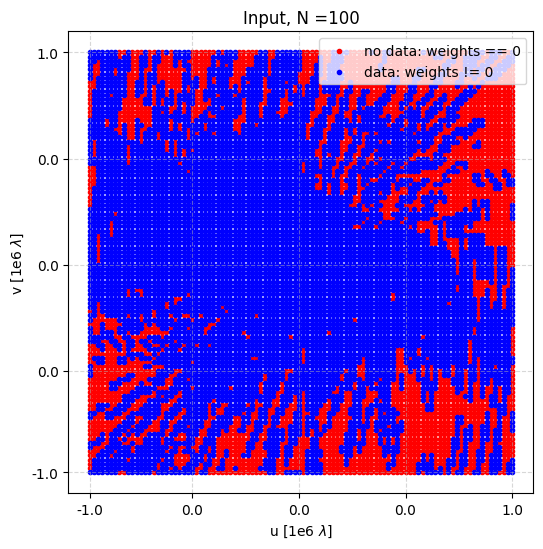

In [20]:
x_no_data, y_no_data = no_data_index_m[:, 1], no_data_index_m[:, 0]
x_data, y_data = data_index_m[:, 1], data_index_m[:, 0]

plt.figure(figsize=(6,6))
#plt.scatter(x_no_data, y_no_data, color='red', marker='.', label='log|no data| < $10^{' + str(threshold)+'}$')
#plt.scatter(x_data, y_data, color='blue', marker='.', label='log|data| > $10^{' + str(threshold)+'}$')
plt.scatter(x_no_data, y_no_data, color='red', marker='.', label='no data: weights == 0')
plt.scatter(x_data, y_data, color='blue', marker='.', label='data: weights != 0')

plt.gca().invert_yaxis()  # Para que el índice 0 esté arriba (como en imshow)
plt.legend(loc = 'upper right')
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.gca().invert_yaxis() 
plt.title(F'Input, N ={N}')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [21]:
len(data_index)

6933

In [22]:
len(data_index)/len(no_data_index)*100

226.05151613955005

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10187/3340702802.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)


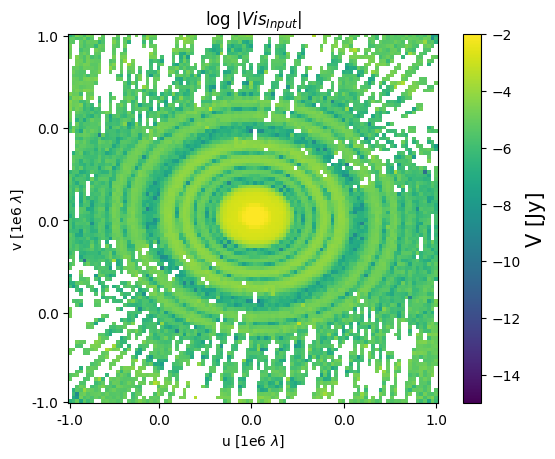

In [23]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-15, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [24]:
# data
u_gridded_data = u_gridded[data_index].flatten()
v_gridded_data = v_gridded[data_index].flatten()
vis_gridded_data  = vis_gridded[data_index].flatten()
weights_gridded_data = weights_gridded[data_index].flatten()

In [25]:
u_gridded_data

array([     0.        ,      0.        ,      0.        , ...,
       -34377.46770785, -34377.46770785, -34377.46770785])

In [26]:
u_gridded_no_data = u_gridded[no_data_index].flatten()
v_gridded_no_data = v_gridded[no_data_index].flatten()
vis_gridded_no_data  = vis_gridded[no_data_index].flatten()
weights_gridded_no_data = weights_gridded[no_data_index].flatten()

### Constructing $S_{11}$

In [27]:
u1_data, u2_data = np.meshgrid(u_gridded_data, u_gridded_data, indexing='ij')
v1_data, v2_data = np.meshgrid(v_gridded_data, v_gridded_data, indexing='ij')

In [28]:
v_min = np.sort(np.abs(np.unique(v_gridded_data)))[1]

In [29]:
print(v_min)

34377.4677078494


In [30]:
m , c,  l = -0.33, -0.1, 2e5

In [31]:
# Paper values for j = 4, k = 1
H_41 = 2*1.897367*l
C_41 = 7/np.pi

In [32]:
data = [u1_data, u2_data, v1_data, v2_data]

In [33]:
def factor_power_spectrum(data, vmin = v_min):
    u1, u2, v1, v2 = data
    q1 = np.hypot(u1, v1)
    q2 = np.hypot(u2, v2)
    min_freq = v_min

    def power_spectrum(q, m, c):
        q[q == 0] = min_freq
        return (q**m)* np.exp(c)

    p1 = power_spectrum(q1, m, c)
    p2 = power_spectrum(q2, m, c)
    
    factor = np.sqrt(p1 * p2)
    return factor

In [34]:
def P_k(r, k):
    if k == 0:
        return np.ones_like(r)  # P_0(r) = 1
    elif k == 1:
        return 4*r +1  # P_1(r) = 4r + 1
    elif k == 2:
        return (35/3)*r**2 +6*r + 1  # P_2(r) = 35r^2 + 18r + 3
    else:
        raise ValueError("k must be 0, 1, or 2.")

In [35]:
def Wendland_kernel(data, amplitude, H, threshold = 1, j = 4, k = 1):
    u1, u2, v1, v2 = data
    r = np.sqrt((u1-u2)**2 + (v1-v2)**2)
    r_normalized = r/H
    factor = (1 - r_normalized)**j
    factor[r_normalized > threshold] = 0
    
    print(r' type?:  ϕ_{', j-k,',',  k, '}')

    return  amplitude * factor * P_k(r_normalized, k)

In [36]:
# Wendland Kernel
matrixW = Wendland_kernel(data, 1, H_41, j = 4, k = 1)

 type?:  ϕ_{ 3 , 1 }


In [37]:
factor = factor_power_spectrum(data)

In [38]:
S_11 = factor * matrixW

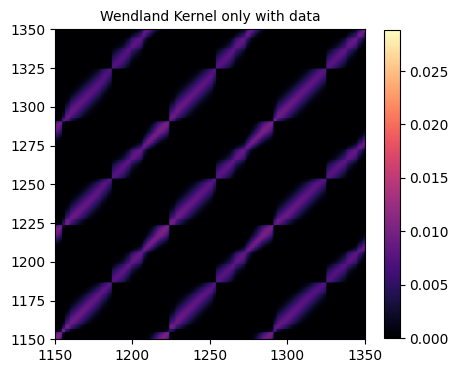

In [39]:
plt.figure(figsize=(5,5))
#plt.pcolormesh(np.hypot(u1_data, v1_data), np.hypot(u2_data, v2_data), S_11, cmap =  'magma')
plt.imshow(S_11, cmap =  'magma', origin='lower')
plt.colorbar(shrink=0.8)
plt.xlim(1150, 1350)
plt.ylim(1150, 1350)
plt.title(r'Wendland Kernel only with data', size = 10)
plt.show()

### Constructing $(I + N^{-1} S_{11})^{-1} N^{-1} V_{data}$

In [40]:
print(weights_gridded_data)

[8.68557037e+05 1.02111297e+08 5.17509058e+07 ... 6.20951962e+07
 7.02930985e+07 2.50356180e+05]


In [41]:
I = np.eye(len(vis_gridded_data))
N_1 = np.diag(weights_gridded_data)

In [42]:
A = I + N_1@S_11

In [43]:
start_time = time.time()
A_1 = np.linalg.inv(A)
end_time = time.time()
execution_time = end_time - start_time
print(f'time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

time = 0.13  min |  7.96 seconds


In [44]:
B = weights_gridded_data * vis_gridded_data

In [45]:
C = np.dot(A_1, B)

### Constructing $S_{12}$

In [46]:
u1_data_nodata, u2_data_nodata = np.meshgrid(u_gridded_data, u_gridded_no_data, indexing='ij')
v1_data_nodata, v2_data_nodata = np.meshgrid(v_gridded_data, v_gridded_no_data, indexing='ij')

In [47]:
data_12 =  [u1_data_nodata, u2_data_nodata, v1_data_nodata, v2_data_nodata]

In [48]:
# Wendland Kernel
matrixW_12 = Wendland_kernel(data_12, 1, H_41, j = 4, k = 1)

 type?:  ϕ_{ 3 , 1 }


In [49]:
factor_12 = factor_power_spectrum(data_12)

In [50]:
S_12 = matrixW_12 * factor_12

In [51]:
S_12_T = np.transpose(S_12)

In [52]:
S_12_T.shape

(3067, 6933)

### Constructing $(I + N^{-1} S_{11})^{-1} N^{-1} V_{data}$  with Conjugate Gradient Method

In [53]:
from scipy.sparse.linalg import LinearOperator
from scipy.sparse.linalg._isolve.utils import make_system
from scipy.sparse.linalg import bicgstab, cg

In [54]:
A.shape

(6933, 6933)

 We intend to solve now:  
    $(I + N^{-1} S_{11})$  V* = $N^{-1} V_{data}$

In [55]:
def linear_op_A(A):
        def mat(vis_model):
            return np.array([ 
                    np.dot(
                        A[i], vis_model)
                    for i in range(A.shape[0])
                    ])
        return LinearOperator(A.shape, matvec = mat)

In [56]:
A_data = linear_op_A(A)
A_precond = np.diag(np.diag(A)**(-1))
b_data = B

In [57]:
x_data, info = bicgstab_(A, B, rtol = 1e-7, M = A_precond, maxiter = 200)

     * BICGSTAB
         * rtol: 1e-07
         * final tolerance: 8.026104458863358
         * maxiter:  200
             .. iteration:  0
             .. iteration:  1
             .. iteration:  2
             .. iteration:  3
             .. iteration:  4
             .. iteration:  5
             .. iteration:  6
             .. iteration:  7
             .. iteration:  8
             .. iteration:  9
             .. iteration:  10
             .. iteration:  11
             .. iteration:  12
             .. iteration:  13
             .. iteration:  14
             .. iteration:  15
             .. iteration:  16
             .. iteration:  17
             .. iteration:  18
             .. iteration:  19
             .. iteration:  20
             .. iteration:  21
             .. iteration:  22
             .. iteration:  23
             .. iteration:  24
             .. iteration:  25
             .. iteration:  26
             .. iteration:  27
             .. iteration:  28
 

In [58]:
C = x_data

### Finding models

In [59]:
V_1_m = np.dot(S_11, C)

In [60]:
V_1_m.shape

(6933,)

In [61]:
V_1_m.flatten()

array([0.2277095 +0.00169007j, 0.22214478+0.00196331j,
       0.18951794+0.00091184j, ..., 0.05921254-0.00012084j,
       0.08876479-0.00043529j, 0.20578356-0.00182995j])

In [62]:
V_1_m

array([0.2277095 +0.00169007j, 0.22214478+0.00196331j,
       0.18951794+0.00091184j, ..., 0.05921254-0.00012084j,
       0.08876479-0.00043529j, 0.20578356-0.00182995j])

In [63]:
V_2_m = np.dot(S_12_T, C)

In [64]:
V_2_m.shape

(3067,)

In [65]:
V_1_m.shape[0] + V_2_m.shape[0]

10000

### Recovering the complete solution

In [66]:
Nx, Ny = N, N  
V_m = np.zeros((Nx, Ny))

data_coords = np.unravel_index(data_index.flatten(), (Nx, Ny))
no_data_coords = np.unravel_index(no_data_index.flatten(), (Nx, Ny))

V_m[data_coords] = V_1_m
V_m[no_data_coords] = V_2_m

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10187/20071317.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  V_m[data_coords] = V_1_m
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_10187/20071317.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  V_m[no_data_coords] = V_2_m


In [67]:
V_m.shape

(100, 100)

In [68]:
V_1_m

array([0.2277095 +0.00169007j, 0.22214478+0.00196331j,
       0.18951794+0.00091184j, ..., 0.05921254-0.00012084j,
       0.08876479-0.00043529j, 0.20578356-0.00182995j])

In [69]:
V_m[data_coords]

array([0.2277095 , 0.22214478, 0.18951794, ..., 0.05921254, 0.08876479,
       0.20578356])

In [70]:
u_m = np.zeros((Nx, Ny))
v_m = np.zeros((Nx, Ny))

u_m[data_coords] = u_gridded_data
u_m[no_data_coords] = u_gridded_no_data

v_m[data_coords] = v_gridded_data
v_m[no_data_coords] = v_gridded_no_data

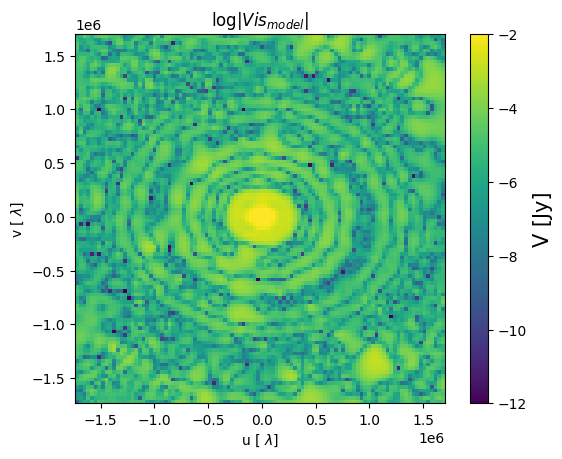

In [71]:
plt.pcolormesh(np.fft.fftshift(v_gridded.reshape(N, N)), np.fft.fftshift(u_gridded).reshape(N,N), np.log(np.abs(np.fft.fftshift(V_m))), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{model}$|')
plt.show()

In [72]:
x_ = frank2d._FT._Xn * rad_to_arcsec
y_ = frank2d._FT._Yn * rad_to_arcsec

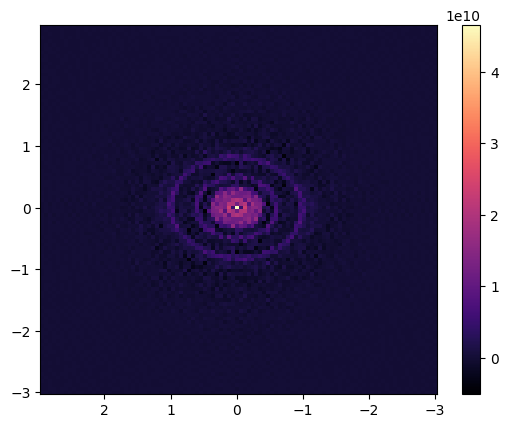

In [73]:
plt.pcolormesh(x_.reshape(N, N), y_.reshape(N, N), np.fft.fftshift(np.fft.ifft2(V_m).real)/(frank2d._FT._dx * frank2d._FT._dy), cmap = 'magma')
plt.gca().invert_xaxis()
plt.colorbar()
plt.show()